https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/text.html  
https://zhuanlan.zhihu.com/p/534904912

In [9]:
import os, sys
from bertviz import head_view, model_view
from transformers import RobertaTokenizer, RobertaConfig
from transformers import RobertaForSequenceClassification

from tokenizers import pre_tokenizers
from safetensors import safe_open
import torch
import torch.nn as nn
import shap
import numpy as np
import scipy as sp
import pandas as pd

sys.path.append("../")
from utils.parameters import *
from train_two_tower_model.two_tower_models import RobertaClassificationHead2

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
bpe_model = RobertaForSequenceClassification.from_pretrained(FINETUNING_MODEL_DIR_BPE_4L8HT2, num_labels=2).to(device)
bpe_model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(10000, 256, padding_idx=1)
      (position_embeddings): Embedding(128, 256, padding_idx=1)
      (token_type_embeddings): Embedding(1, 256)
      (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-3): 4 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              (distance_embedding): Embedding(255, 32)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in

In [11]:
positive_dataset = pd.read_csv(os.path.join(SAMPLES_PATH, "distinct_positive_samples_HEK293T.csv"), header=None)
negative_dataset = pd.read_csv(os.path.join(SAMPLES_PATH, "distinct_negative_samples_HEK293T.csv"), header=None)
pseudo_pos_dataset = pd.read_csv(os.path.join(PSEUDO_SAMPLES_PATH, "pseudo_positive_samples_HEK293T_v2.csv"), header=None)
pseudo_neg_dataset = pd.read_csv(os.path.join(PSEUDO_SAMPLES_PATH, "pseudo_negative_samples_HEK293T_v2.csv"), header=None)
print(f"number of positive samples: {positive_dataset.shape[0]}")
print(f"number of negative samples: {negative_dataset.shape[0]}")
print(f"number of pseudo positive samples: {pseudo_pos_dataset.shape[0]}")
print(f"number of pseudo negative samples: {pseudo_neg_dataset.shape[0]}")
positive_dataset = positive_dataset.sample(n=100, replace=False, random_state=42)
negative_dataset = negative_dataset.sample(n=100, replace=False, random_state=42)
pseudo_pos_dataset = pseudo_pos_dataset.sample(n=100, replace=False, random_state=42)
pseudo_neg_dataset = pseudo_neg_dataset.sample(n=100, replace=False, random_state=42)

number of positive samples: 13708
number of negative samples: 28717
number of pseudo positive samples: 10276
number of pseudo negative samples: 2137


In [12]:
candidate_seqs2 = [(-4.281908988952637, 'CCCCCCCGCGCGGCCCCGCCCCC'),
                  (-4.243957996368408, 'CCCCCCCGCCCCCGCCACCCCGCACCCCGCCCCCCGGCATGGCTTTCCCC'),
                  (-4.230985641479492, 'CCCCGCCCATCTTCCAGGCCCCGCCC'),
                  (-4.230202674865723, 'CCCCCGGCCCGGCCTCAGGCCCCGCCC'),
                  (-4.230099678039551, 'CCCCGCCTCCCGTCGGCCCGCCCCCAAACCCCGCCC'),
                  (-4.218786716461182, 'CCCCACCCCTTACCGCCTGGCCCCGCCCACGCCCC'),
                  (-4.208957195281982, 'CCCCACCCTCCTTCGGGCCCCGCCCCTCCCCTCCCC'),
                  (-4.207056999206543, 'CCCGCCCCGCCCCGCCCCTTGGCCTGAAGACCCCGCCC'),
                  (-4.196073055267334, 'CCCTCATAGGCCACGCCCCGGACCCGCCCCCC'),
                  (-4.193173408508301, 'CCCGCCCAGGACCTAGCCCCGCCC')]
sentence_a = negative_dataset.to_numpy()[:,0][0]
seqs = [i[1] for i in candidate_seqs2]

tokenizer1 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BASE)
tokenizer2 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BPE)
# tokenizer2.pre_tokenizer = pre_tokenizers.Whitespace()

# input_ids_1 = tokenizer1(sentence_a, padding="max_length", max_length=MAX_LEN_BASE, return_tensors='pt')["input_ids"].to(device)
# print(input_ids_1)
input_ids_2 = tokenizer2(sentence_a, padding="max_length", max_length=MAX_LEN_BPE, return_tensors='pt')["input_ids"].to(device)
print(input_ids_2)
tokens_2 = tokenizer2.convert_ids_to_tokens(input_ids_2[0])
print(tokens_2)

outputs = bpe_model(input_ids_2)
print(outputs)

tensor([[   0,    8,  370,    5, 1125,    5, 2141,    6,    1,    3,    3,    3,
            3,    3,    3,    3,    3,    3,    3,    3,    3,    3]],
       device='cuda:0')
['<s>', 'CCCCCC', 'ATGA', 'CCC', 'AAACACCT', 'CCC', 'ACCAGA', 'CCCC', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
SequenceClassifierOutput(loss=None, logits=tensor([[-0.5871,  0.4084]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


In [13]:
# define a prediction function
def f(x):
    # print(x)
    tv = torch.tensor([tokenizer2.encode(v, padding="max_length", max_length=MAX_LEN_BPE, truncation=True) for v in x]).cuda()
    # print(tv)
    outputs = bpe_model(tv)[0].detach().cpu().numpy()
    # print("outputs:")
    # print(outputs)
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    # print("scores:")
    # print(scores)
    val = sp.special.logit(scores[:, 1])  # use one vs rest logit units
    # print("val")
    # print(val)
    return val

# build an explainer using a token masker
explainer = shap.Explainer(f, tokenizer2, seed=42)

In [14]:
# shap_values = explainer([sentence_a], fixed_context=1)
# shap_values = explainer(seqs[3:5], fixed_context=1)
# print(shap_values)
# shap.plots.text(shap_values)

In [15]:
# sim_seqs = ["CCCGGCCCGGCCCGGCCC",
#             "CCCTTCCCTTCCCTTCCC",
#             "CCCTTCCCTTTTCCCTTCCC",
#             "CCCTTCCCTTTTTTCCCTTCCC",
#             "CCCAACCCAACCCAACCC",
#             "CCCCCCCCCCCCCCCCCC"]
# sim_shap_values = explainer(sim_seqs, fixed_context=1)
# shap.plots.text(sim_shap_values)

In [16]:
pos_shap_values = explainer(positive_dataset.to_numpy()[:,0].tolist(), fixed_context=1)
neg_shap_values = explainer(negative_dataset.to_numpy()[:,0].tolist(), fixed_context=1)
pseudo_pos_shap_values = explainer(pseudo_pos_dataset.to_numpy()[:,0].tolist(), fixed_context=1)
pseudo_neg_shap_values = explainer(pseudo_neg_dataset.to_numpy()[:,0].tolist(), fixed_context=1)

In [26]:
# shap.plots.text(pos_shap_values[0:10])
# shap.plots.text(pos_shap_values[0])
# shap.plots.text(pos_shap_values[3])
# shap.plots.text(pos_shap_values[5])
# shap.plots.text(pos_shap_values[7])
shap.plots.text(pos_shap_values[[0,3,5,7]])

In [27]:
# shap.plots.text(neg_shap_values[0:10])
# shap.plots.text(neg_shap_values[0])
# shap.plots.text(neg_shap_values[2])
# shap.plots.text(neg_shap_values[3])
# shap.plots.text(neg_shap_values[5])
shap.plots.text(neg_shap_values[[0,2,3,5]])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


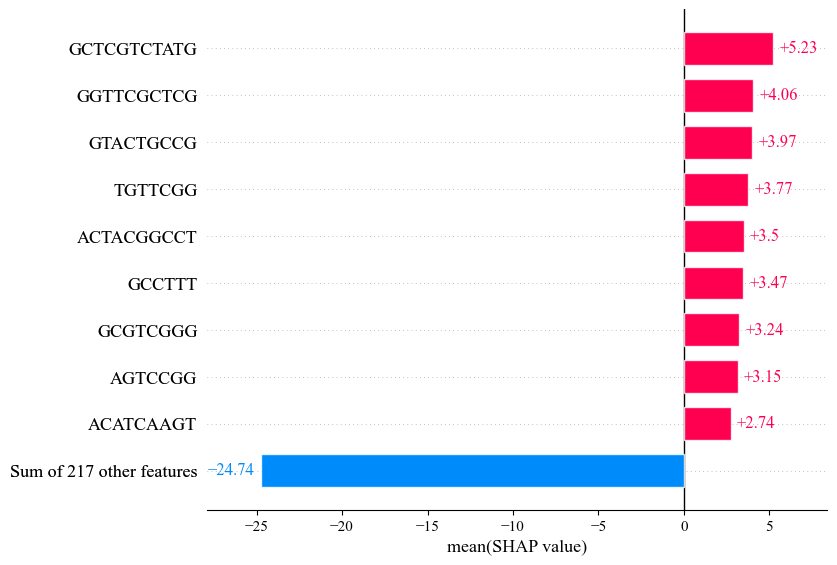

In [19]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
shap.plots.bar(pos_shap_values.mean(0), show=False)
plt.savefig("../figures/shap_pos.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


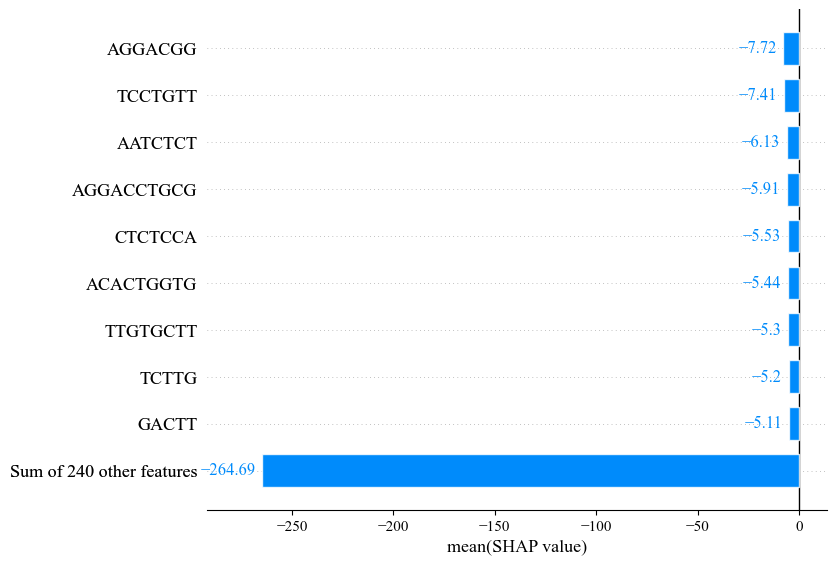

In [20]:
shap.plots.bar(neg_shap_values.mean(0), show=False)
plt.savefig("../figures/shap_neg.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


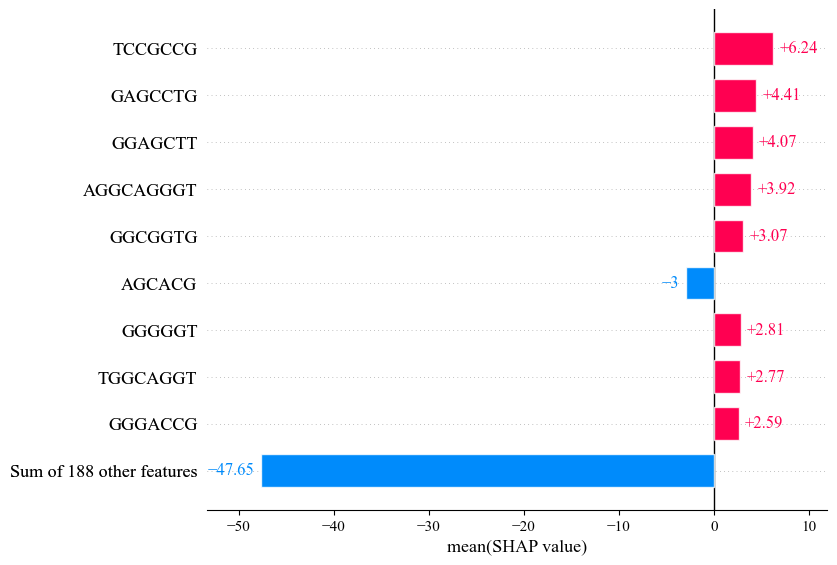

In [21]:
shap.plots.bar(pseudo_pos_shap_values.mean(0), show=False)
plt.savefig("../figures/shap_pseudo_pos.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


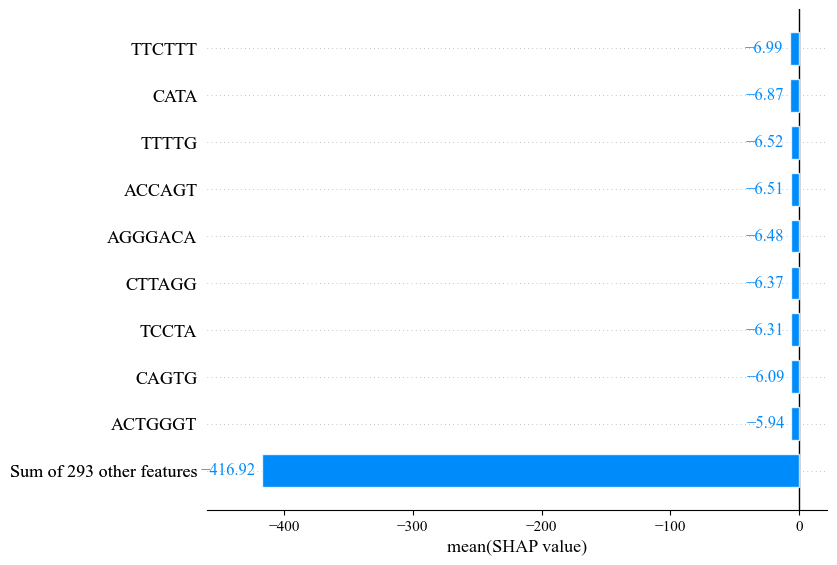

In [22]:
shap.plots.bar(pseudo_neg_shap_values.mean(0), show=False)
plt.savefig("../figures/shap_pseudo_neg.eps", format="eps", bbox_inches="tight")

In [23]:
# shap.plots.bar(shap_values.abs.sum(0))
# shap.plots.bar(shap_values.abs.max(0))
# shap.plots.waterfall(shap_values[0], max_display=20)
# shap.plots.bar(shap_values.max(0), max_display=10)